# Problem 1: Topic Modeling with Latent Dirichlet Allocation (LDA)

## Imports and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import nltk
import spacy
from gensim import corpora
from gensim.models import LdaModel
import numpy as np
from typing import List, Tuple
import re

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

nlp = spacy.load('en_core_web_sm')

## Helper Functions

In [2]:
def preprocess_text(text: str) -> List[str]:
    """Preprocess: lowercase, remove stopwords, lemmatize."""
    text = text.lower()
    text = re.sub(r'\$[^$]+\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+', '', text)
    text = re.sub(r'\[\^?\d+\]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 2
    ]
    return tokens

def clean_preview_text(text: str) -> str:
    """Clean text for display by removing LaTeX, footnotes, and special formatting."""
    # Remove inline math: $...$
    text = re.sub(r'\$[^$]+\$', '', text)
    # Remove LaTeX commands
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'\\[a-zA-Z]+', '', text)
    # Remove backslash characters
    text = re.sub(r'\\', '', text)
    # Remove footnote markers and references: [^0], [1], etc.
    text = re.sub(r'\[\^?\d+\]', '', text)
    # Remove entire footnote content blocks
    text = re.sub(r'\[\^?\d+\]:\s*[^\n]+', '', text)
    # Remove markdown tables (they don't preview well when truncated)
    text = re.sub(r'\|[^\n]+\|', '[Table]', text)
    # Remove page markers
    text = re.sub(r'---\s*Page\s*\d+', '', text)
    # Remove standalone colons left from footnotes
    text = re.sub(r'\s+:\s+', ' ', text)
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [3]:
def get_topic_label(top_words: List[Tuple[str, float]]) -> str:
    """Generate 2-3 word label from top words."""
    words = [word for word, prob in top_words[:7]]
    word_str = ' '.join(words).lower()

    if any(w in word_str for w in ['agent', 'triage', 'tool', 'call', 'user', 'query']):
        return "Agent Systems"
    elif any(w in word_str for w in ['node', 'edge', 'path', 'centrality', 'traversal']):
        return "Network Paths"
    elif any(w in word_str for w in ['factor', 'portfolio', 'security', 'stock', 'shell']):
        return "Financial Analysis"
    elif any(w in word_str for w in ['supply', 'chain', 'coltan', 'apple', 'drc']):
        return "Supply Chain"
    elif any(w in word_str for w in ['model', 'time', 'domain', 'hop', 'summary']):
        return "Graph Traversal"
    elif any(w in word_str for w in ['graph', 'network', 'llm', 'retrieval']):
        if 'llm' in word_str or 'language' in word_str:
            return "LLM Applications"
        else:
            return "Knowledge Graphs"
    else:
        return ' '.join(words[:2]).title()

## (a) Article Selection and Topic Estimation

In [4]:
print("="*80)
print("PROBLEM 1: LDA TOPIC MODELING - SOLUTION REPORT")
print("="*80)

print("\n(a) ARTICLE SELECTION AND TOPIC ESTIMATION")
print("-"*80)

with open('article-sections.json', 'r', encoding='utf-8') as f:
    article_data = json.load(f)

sections = []
for item in article_data:
    sections.append({
        'header': item['section'],
        'content': item['content']
    })

print(f"Article: 'Network-Knowledge Graph Duality in Supply Chain Risk Analysis'")
print(f"Total sections (documents): {len(sections)}")
print(f"\nManual topic estimation: 6 topics")

PROBLEM 1: LDA TOPIC MODELING - SOLUTION REPORT

(a) ARTICLE SELECTION AND TOPIC ESTIMATION
--------------------------------------------------------------------------------
Article: 'Network-Knowledge Graph Duality in Supply Chain Risk Analysis'
Total sections (documents): 11

Manual topic estimation: 6 topics


## (b) Data Preparation

In [5]:
print("\n\n(b) DATA PREPARATION")
print("-"*80)

documents = [sec['content'] for sec in sections]
print("Preprocessing: lowercase, stopword removal, lemmatization\n")

processed_docs = [preprocess_text(doc) for doc in documents]

print("Sample processed paragraphs:\n")
for i in range(min(3, len(processed_docs))):
    print(f"Section {i+1}: {sections[i]['header']}")
    print(f"  Original: {documents[i][:100]}...")
    print(f"  Processed: {' '.join(processed_docs[i][:20])}...")
    print(f"  Tokens: {len(processed_docs[i])}\n")



(b) DATA PREPARATION
--------------------------------------------------------------------------------
Preprocessing: lowercase, stopword removal, lemmatization

Sample processed paragraphs:

Section 1: # Exploring Network-Knowledge Graph Duality: A Case Study in Agentic Supply Chain Risk Analysis
  Original: Evan Heus ${ }^{\star}$<br>University of California, Berkeley<br>Berkeley, CA, USA<br>MSCI<br>New Yo...
  Processed: evan heus university california berkeley berkeley usa msci new york usa evheus berkeley edu...
  Tokens: 14

Section 2: ## Abstract
  Original: Large Language Models (LLMs) struggle with the complex, multimodal, and network-native data underlyi...
  Processed: large language model llm struggle complex multimodal network native datum underlie financial risk standard retrieval augment generation rag oversimplifie relationship...
  Tokens: 113

Section 3: ## 1 Introduction
  Original: Large language models (LLMs) are increasingly embedded in critical, high-stakes deci

Sample processed paragraphs:

Section 1: # Exploring Network-Knowledge Graph Duality: A Case Study in Agentic Supply Chain Risk Analysis
  Original: Evan Heus ${ }^{\star}$<br>University of California, Berkeley<br>Berkeley, CA, USA<br>MSCI<br>New Yo...
  Processed: evan heus university california berkeley berkeley usa msci new york usa evheus berkeley edu...
  Tokens: 14

Section 2: ## Abstract
  Original: Large Language Models (LLMs) struggle with the complex, multimodal, and network-native data underlyi...
  Processed: large language model llm struggle complex multimodal network native datum underlie financial risk standard retrieval augment generation rag oversimplifie relationship...
  Tokens: 113

Section 3: ## 1 Introduction
  Original: Large language models (LLMs) are increasingly embedded in critical, high-stakes decision processes, ...
  Processed: large language model llm increasingly embed critical high stake decision process medical diagnostic triage financial advice domain

## (c) LDA Model Implementation

In [6]:
print("\n(c) LDA MODEL IMPLEMENTATION")
print("-"*80)

dictionary = corpora.Dictionary(processed_docs)
dictionary.filter_extremes(no_below=1, no_above=0.7)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print(f"Dictionary size: {len(dictionary)} terms")
print(f"Training LDA model with 6 topics...")


(c) LDA MODEL IMPLEMENTATION
--------------------------------------------------------------------------------
Dictionary size: 822 terms
Training LDA model with 6 topics...


In [7]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    random_state=42,
    passes=20,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

print("Model trained successfully.")

Model trained successfully.


## (d) Results Presentation

In [8]:
print("\n\n(d) RESULTS PRESENTATION")
print("-"*80)

doc_topic_dist = []
for doc_bow in corpus:
    topic_dist = lda_model.get_document_topics(doc_bow)
    full_dist = [0.0] * 6
    for topic_id, prob in topic_dist:
        full_dist[topic_id] = prob
    doc_topic_dist.append(full_dist)

doc_topic_matrix = np.array(doc_topic_dist)



(d) RESULTS PRESENTATION
--------------------------------------------------------------------------------


In [9]:
for topic_id in range(6):
    print(f"\n{'='*80}")
    print(f"TOPIC {topic_id}")
    print(f"{'='*80}")

    topic_terms = lda_model.show_topic(topic_id, topn=10)
    print("\nTop 10 words:")
    for rank, (word, prob) in enumerate(topic_terms, 1):
        print(f"  {rank:2d}. {word:20s} ({prob:.4f})")

    label = get_topic_label(topic_terms)
    print(f"\nLabel: {label}")

    topic_scores = doc_topic_matrix[:, topic_id]
    top_doc_indices = np.argsort(topic_scores)[::-1][:2]

    print(f"\nTop 2 most associated documents:")
    for rank, doc_idx in enumerate(top_doc_indices, 1):
        score = topic_scores[doc_idx]
        section_header = sections[doc_idx]['header']
        section_content = sections[doc_idx]['content']
        
        # Clean the preview text to remove LaTeX, footnotes, tables
        cleaned_content = clean_preview_text(section_content)
        preview = cleaned_content[:200] + "..." if len(cleaned_content) > 200 else cleaned_content

        print(f"\n  Document {rank} (Score: {score:.4f})")
        print(f"  Section: {section_header}")
        print(f"  Preview: {preview}")

print("\n" + "="*80)
print("END OF REPORT")
print("="*80)


TOPIC 0

Top 10 words:
   1. graph                (0.0012)
   2. llm                  (0.0012)
   3. network              (0.0012)
   4. supply               (0.0012)
   5. factor               (0.0012)
   6. context              (0.0012)
   7. chain                (0.0012)
   8. risk                 (0.0012)
   9. agent                (0.0012)
  10. knowledge            (0.0012)

Label: Financial Analysis

Top 2 most associated documents:

  Document 1 (Score: 0.0000)
  Section: ## A Knowledge-Graph Details
  Preview: Table 1: Relationships by Entity Type for the knowledge graph. [Table] [Table] [Table] [Table] [Table] [Table] Figure 4: Knowledge-graph relationship diagram. ![img-3.jpeg](img-3.jpeg)

  Document 2 (Score: 0.0000)
  Section: ## 8 Conclusion and Next Steps
  Preview: Summary. Our proposed framework demonstrates that a frozen general purpose LLM can operate as a domain expert when paired with three carefully engineered data modes. MSCI MAC factor models, curated ne...

T

# Problem 2: Optimal Topic Selection with Coherence and Exclusivity

## Additional Imports for Problem 2

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import CoherenceModel

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## (a) Data Utilization

Using the same preprocessed data from Problem 1:

In [11]:
print("="*80)
print("PROBLEM 2: OPTIMAL TOPIC SELECTION")
print("="*80)

print("\n(a) DATA UTILIZATION")
print("-"*80)
print(f"Reusing preprocessed data from Problem 1:")
print(f"  - Documents: {len(processed_docs)} paragraphs")
print(f"  - Dictionary: {len(dictionary)} unique terms")
print(f"  - Corpus: {len(corpus)} document-term vectors")

PROBLEM 2: OPTIMAL TOPIC SELECTION

(a) DATA UTILIZATION
--------------------------------------------------------------------------------
Reusing preprocessed data from Problem 1:
  - Documents: 11 paragraphs
  - Dictionary: 822 unique terms
  - Corpus: 11 document-term vectors


## (b) LDA Model Implementation and Evaluation

Testing LDA models with topic counts from 2 to 10, computing coherence and exclusivity for each:

In [12]:
def calculate_exclusivity(model, num_topics, top_n=15):
    """
    Calculate exclusivity by measuring word overlap among topics.
    Higher exclusivity = less overlap = more distinct topics.
    
    Returns a score between 0 and 1, where 1 means perfect exclusivity (no overlap).
    """
    # Get top N words for each topic
    topic_words = []
    for topic_id in range(num_topics):
        words = [word for word, prob in model.show_topic(topic_id, topn=top_n)]
        topic_words.append(set(words))
    
    # Calculate pairwise overlap
    total_pairs = 0
    total_overlap = 0
    
    for i in range(num_topics):
        for j in range(i + 1, num_topics):
            overlap = len(topic_words[i].intersection(topic_words[j]))
            total_overlap += overlap
            total_pairs += 1
    
    # Average overlap per pair
    avg_overlap = total_overlap / total_pairs if total_pairs > 0 else 0
    
    # Convert to exclusivity (inverse of overlap, normalized)
    # Maximum possible overlap is top_n words
    exclusivity = 1.0 - (avg_overlap / top_n)
    
    return exclusivity

In [13]:
print("\n(b) LDA MODEL IMPLEMENTATION AND EVALUATION")
print("-"*80)

# Range of topic numbers to test
topic_range = range(2, 11)  # 2 to 10 inclusive

# Storage for results
models = {}
coherence_scores = []
exclusivity_scores = []

print("Training LDA models and computing metrics...\n")

for num_topics in topic_range:
    print(f"Training model with {num_topics} topics...", end=" ")
    
    # Train LDA model
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20,
        alpha='auto',
        eta='auto',
        per_word_topics=True
    )
    models[num_topics] = lda
    
    # Calculate coherence
    coherence_model = CoherenceModel(
        model=lda,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    
    # Calculate exclusivity
    exclusivity = calculate_exclusivity(lda, num_topics, top_n=15)
    exclusivity_scores.append(exclusivity)
    
    print(f"Coherence: {coherence:.4f}, Exclusivity: {exclusivity:.4f}")

print("\nModel training and evaluation complete!")


(b) LDA MODEL IMPLEMENTATION AND EVALUATION
--------------------------------------------------------------------------------
Training LDA models and computing metrics...

Coherence: 0.3046, Exclusivity: 0.7333
Coherence: 0.4098, Exclusivity: 0.6889
Coherence: 0.3672, Exclusivity: 0.7333
Coherence: 0.4000, Exclusivity: 0.7733
Coherence: 0.4030, Exclusivity: 0.7644
Coherence: 0.3823, Exclusivity: 0.7460
Coherence: 0.3925, Exclusivity: 0.7476
Coherence: 0.3678, Exclusivity: 0.6648
Coherence: 0.4557, Exclusivity: 0.7156

Model training and evaluation complete!


Coherence: 0.3046, Exclusivity: 0.7333
Training model with 3 topics... 

Coherence: 0.4098, Exclusivity: 0.6889
Training model with 4 topics... 

Coherence: 0.3672, Exclusivity: 0.7333
Training model with 5 topics... 

Coherence: 0.4000, Exclusivity: 0.7733
Training model with 6 topics... 

Coherence: 0.4030, Exclusivity: 0.7644
Training model with 7 topics... 

Coherence: 0.3823, Exclusivity: 0.7460
Training model with 8 topics... 

Coherence: 0.3925, Exclusivity: 0.7476
Training model with 9 topics... 

Coherence: 0.3678, Exclusivity: 0.6648
Training model with 10 topics... 

Coherence: 0.4557, Exclusivity: 0.7156

Model training and evaluation complete!


## (c) Optimal Topic Selection

Normalizing metrics to [0,1] range and calculating composite score:

In [14]:
print("\n(c) OPTIMAL TOPIC SELECTION")
print("-"*80)

# Convert to numpy arrays
coherence_arr = np.array(coherence_scores)
exclusivity_arr = np.array(exclusivity_scores)
topic_numbers = np.array(list(topic_range))

# Normalize to [0, 1] range using min-max scaling
def normalize(values):
    """Min-max normalization to [0, 1] range."""
    min_val = values.min()
    max_val = values.max()
    if max_val - min_val == 0:
        return np.ones_like(values)
    return (values - min_val) / (max_val - min_val)

coherence_normalized = normalize(coherence_arr)
exclusivity_normalized = normalize(exclusivity_arr)

# Calculate composite score
composite_scores = 0.5 * coherence_normalized + 0.5 * exclusivity_normalized

# Find optimal number of topics
optimal_idx = np.argmax(composite_scores)
optimal_topics = topic_numbers[optimal_idx]

print("Normalized Metrics:")
print(f"{'Topics':<10} {'Coherence':<12} {'Exclusivity':<12} {'Composite':<12}")
print("-" * 50)
for i, n_topics in enumerate(topic_numbers):
    marker = " <-- OPTIMAL" if n_topics == optimal_topics else ""
    print(f"{n_topics:<10} {coherence_normalized[i]:<12.4f} {exclusivity_normalized[i]:<12.4f} {composite_scores[i]:<12.4f}{marker}")

print(f"\nOptimal number of topics: {optimal_topics}")
print(f"Composite score: {composite_scores[optimal_idx]:.4f}")


(c) OPTIMAL TOPIC SELECTION
--------------------------------------------------------------------------------
Normalized Metrics:
Topics     Coherence    Exclusivity  Composite   
--------------------------------------------------
2          0.0000       0.6314       0.3157      
3          0.6960       0.2218       0.4589      
4          0.4144       0.6314       0.5229      
5          0.6314       1.0000       0.8157       <-- OPTIMAL
6          0.6510       0.9181       0.7846      
7          0.5141       0.7484       0.6313      
8          0.5815       0.7630       0.6723      
9          0.4182       0.0000       0.2091      
10         1.0000       0.4676       0.7338      

Optimal number of topics: 5
Composite score: 0.8157


### Visualization of Metrics

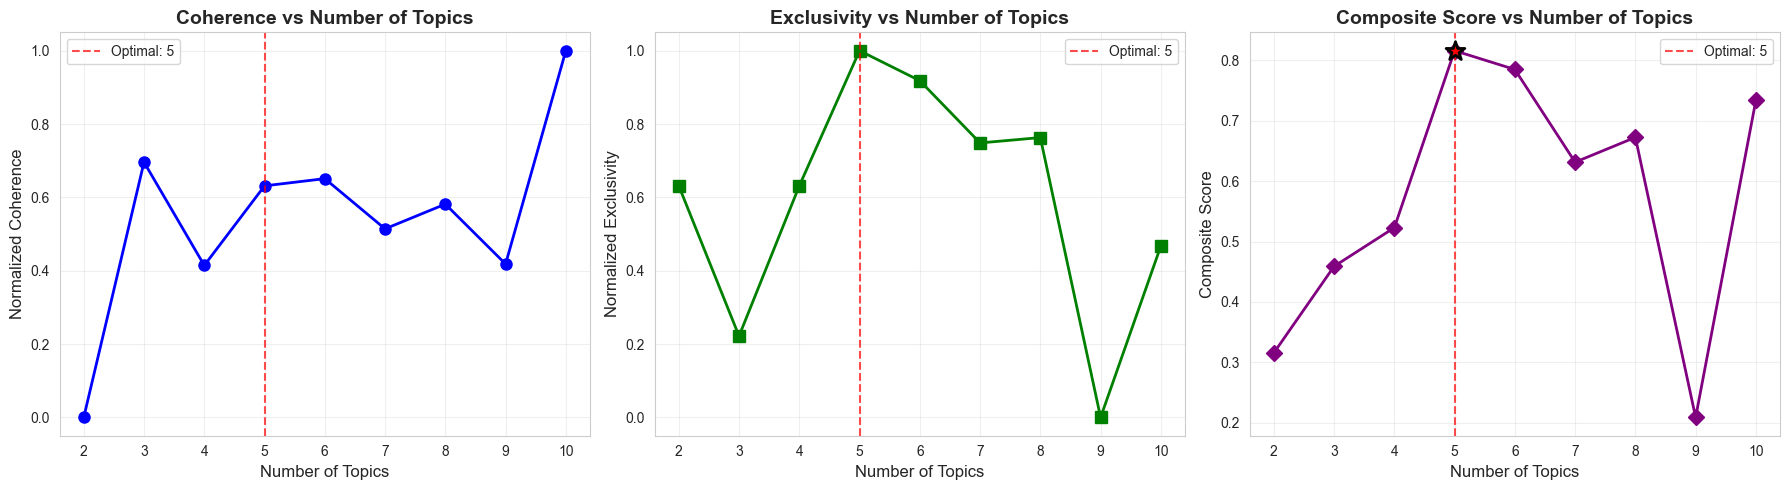


Justification for Optimal Topic Selection:
--------------------------------------------------------------------------------
The optimal number of topics is 5, which achieves the highest composite
score of 0.8157. This represents the best balance between:
  • Coherence (how semantically related words are within topics)
  • Exclusivity (how distinct topics are from each other)

This configuration maximizes both interpretability and topic distinctiveness.


In [15]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Coherence
axes[0].plot(topic_numbers, coherence_normalized, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].axvline(x=optimal_topics, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_topics}')
axes[0].set_xlabel('Number of Topics', fontsize=12)
axes[0].set_ylabel('Normalized Coherence', fontsize=12)
axes[0].set_title('Coherence vs Number of Topics', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(topic_numbers)

# Plot 2: Exclusivity
axes[1].plot(topic_numbers, exclusivity_normalized, marker='s', linewidth=2, markersize=8, color='green')
axes[1].axvline(x=optimal_topics, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_topics}')
axes[1].set_xlabel('Number of Topics', fontsize=12)
axes[1].set_ylabel('Normalized Exclusivity', fontsize=12)
axes[1].set_title('Exclusivity vs Number of Topics', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(topic_numbers)

# Plot 3: Composite Score
axes[2].plot(topic_numbers, composite_scores, marker='D', linewidth=2, markersize=8, color='purple')
axes[2].axvline(x=optimal_topics, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_topics}')
axes[2].scatter([optimal_topics], [composite_scores[optimal_idx]], color='red', s=200, zorder=5, 
                marker='*', edgecolors='black', linewidths=2)
axes[2].set_xlabel('Number of Topics', fontsize=12)
axes[2].set_ylabel('Composite Score', fontsize=12)
axes[2].set_title('Composite Score vs Number of Topics', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xticks(topic_numbers)

plt.tight_layout()
plt.show()

print("\nJustification for Optimal Topic Selection:")
print("-" * 80)
print(f"The optimal number of topics is {optimal_topics}, which achieves the highest composite")
print(f"score of {composite_scores[optimal_idx]:.4f}. This represents the best balance between:")
print(f"  • Coherence (how semantically related words are within topics)")
print(f"  • Exclusivity (how distinct topics are from each other)")
print(f"\nThis configuration maximizes both interpretability and topic distinctiveness.")

## (d) Results Presentation

Presenting the optimal model's topics with top 10 words, 2 most associated documents, and topic labels:

In [16]:
print("\n(d) RESULTS PRESENTATION - OPTIMAL MODEL")
print("="*80)

# Get the optimal model
optimal_model = models[optimal_topics]

# Calculate document-topic distributions for the optimal model
doc_topic_dist = []
for doc_bow in corpus:
    topic_dist = optimal_model.get_document_topics(doc_bow)
    full_dist = [0.0] * optimal_topics
    for topic_id, prob in topic_dist:
        full_dist[topic_id] = prob
    doc_topic_dist.append(full_dist)

doc_topic_matrix = np.array(doc_topic_dist)

# Present each topic
for topic_id in range(optimal_topics):
    print(f"\n{'='*80}")
    print(f"TOPIC {topic_id}")
    print(f"{'='*80}")
    
    # Get top 10 words
    topic_terms = optimal_model.show_topic(topic_id, topn=10)
    print("\nTop 10 Most Frequent Words:")
    for rank, (word, prob) in enumerate(topic_terms, 1):
        print(f"  {rank:2d}. {word:20s} ({prob:.4f})")
    
    # Generate topic label
    label = get_topic_label(topic_terms)
    print(f"\nTopic Label: {label}")
    
    # Find top 2 most associated documents
    topic_scores = doc_topic_matrix[:, topic_id]
    top_doc_indices = np.argsort(topic_scores)[::-1][:2]
    
    print(f"\nTop 2 Most Associated Documents (Paragraphs):")
    for rank, doc_idx in enumerate(top_doc_indices, 1):
        score = topic_scores[doc_idx]
        section_header = sections[doc_idx]['header']
        section_content = sections[doc_idx]['content']
        
        # Clean the preview text to remove LaTeX, footnotes, tables
        cleaned_content = clean_preview_text(section_content)
        preview = cleaned_content[:200] + "..." if len(cleaned_content) > 200 else cleaned_content
        
        print(f"\n  Document {rank} (Association Score: {score:.4f})")
        print(f"  Section: {section_header}")
        print(f"  Preview: {preview}")

print("\n" + "="*80)
print("END OF PROBLEM 2 REPORT")
print("="*80)


(d) RESULTS PRESENTATION - OPTIMAL MODEL

TOPIC 0

Top 10 Most Frequent Words:
   1. graph                (0.0136)
   2. factor               (0.0136)
   3. news                 (0.0136)
   4. context              (0.0110)
   5. input                (0.0110)
   6. knowledge            (0.0084)
   7. tool                 (0.0084)
   8. system               (0.0084)
   9. query                (0.0084)
  10. portfolio            (0.0084)

Topic Label: Agent Systems

Top 2 Most Associated Documents (Paragraphs):

  Document 1 (Association Score: 0.9995)
  Section: ## 4 Data Modes And Tools
  Preview: Our system operates on three external data channels that complement the conversation context and the user's portfolio. Each is A request is termed a compound query when it references two or more disti...

  Document 2 (Association Score: 0.0000)
  Section: ## A Knowledge-Graph Details
  Preview: Table 1: Relationships by Entity Type for the knowledge graph. [Table] [Table] [Table] [Table] [Ta